# Aula 15

# Geração de texto com rede neural transformador

### Eduardo Lobo Lustosa Cabral

## 1. Introdução e objetivos

O objetivo dessa aula é apresentar como gerar textos originais usando uma rede neural tipo transformador.

A rede neural utilizada consiste em uma versão miniatura do modelo GPT, que implementa um modelo de linguagem autorregressivo.

O modelo é composto por um único bloco transformador com uma máscara causal na camada de atenção.

O conjunto de dados usado no treinamento do modelo é o UTL-Movies, que consiste de opiniões sobre filmes em português.

Esse conjunto de textos pode ser obtido em https://github.com/RogerFig/UTLCorpus ou no Kaggle em https://www.kaggle.com/datasets/fredericods/ptbr-sentiment-analysis-datasets?resource=download&select=utlc_movies.

Mais informações sobre o conjunto de dados podem ser obtidas em: "SOUSA, R. F.; BRUM, H. B.; NUNES, M. G. V. A bunch of helpfulness and sentiment corpora in brazilian portuguese. In: SOCIEDADE BRASILEIRA DE COMPUTAÇÃO. Proceedings of Symposium in Information and Human Language Technology - STIL. Salvador - BA, 2019".

Após treinado, o modelo é capaz de gerar novas opiniões sobre filmes a partir de algumas palavras iniciais.

Detalhes sobre o GPT, incluindo configuração e treino podem ser encontrados em:

- GPT: https://www.semanticscholar.org/paper/Improving-Language-Understanding-by-Generative-Radford/cd18800a0fe0b668a1cc19f2ec95b5003d0a5035
- GPT-2: https://www.semanticscholar.org/paper/Language-Models-are-Unsupervised-Multitask-Learners-Radford-Wu/9405cc0d6169988371b2755e573cc28650d14dfe
- GPT-3: https://arxiv.org/abs/2005.14165

Esse notebook é basedo em: Apoorv Nandan, Implement a miniature version of GPT and train it to generate text (https://colab.research.google.com/github/keras-team/keras-io/blob/master/examples/generative/ipynb/text_generation_with_miniature_gpt.ipynb).

### Importação das principais bibliotecas

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import TextVectorization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
tf.__version__

'2.19.0'

## 2. Processamento dos dados

O conjunto de dados UTL-Movies contém cerca de 1,5 milhões de revisões sobre filmes em português coletados da Filmow, que é uma rede social de filmes.

As revisões possuem comprimento médio de 42 palavras, sendo que a maior possui 11.473 palavras e a menor nenhuma palavra.

O vocabulário dessas revisões contém 69.771 palavras.

O conjunto de dados usado foi obtido do Kaggle em: https://www.kaggle.com/datasets/fredericods/ptbr-sentiment-analysis-datasets?resource=download&select=utlc_movies.

### 2.1 Obtenção dos dados

Os dados estão em um arquivo compactado tipo CSV, portanto, vamos descompactar o aequivo e depois carregá-lo em um DataFrame pandas.

https://drive.google.com/file/d/1eNcePR8aQO0rb0R3kyEDgOCp4zzS20lB/view?usp=drive_link

In [ ]:
# Conectar o google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Descompactar o arquivo de revisões
!unzip /content/drive/MyDrive/utlc_movies.csv.zip -d /content/

Archive:  /content/drive/MyDrive/utlc_movies.csv.zip
  inflating: /content/utlc_movies.csv  


In [ ]:
# Carregar dados em dataframe pandas
movies = pd.read_csv('/content/utlc_movies.csv')
print('Dimensão dos dados:', movies.shape)
movies.head(20)

Dimensão dos dados: (1487449, 8)


,original_index,review_text,review_text_processed,review_text_tokenized,polarity,rating,kfold_polarity,kfold_rating
0,214389,Um dos melhores desenhos!!,um dos melhores desenhos!!,"['um', 'dos', 'melhores', 'desenhos']",1.0,4,1,1
1,54616,O filme é realmente diferente e bem lento mas ...,o filme e realmente diferente e bem lento mas ...,"['filme', 'realmente', 'diferente', 'bem', 'le...",1.0,4,1,1
2,504263,"Hilário em alguns momentos, e muito bem feito.","hilario em alguns momentos, e muito bem feito.","['hilario', 'em', 'alguns', 'momentos', 'muito...",1.0,4,1,1
3,963792,choro toda vez que vejo :(,choro toda vez que vejo :(,"['choro', 'toda', 'vez', 'que', 'vejo']",1.0,5,1,1
4,1208949,Niiiice!,niiiice!,['niiiice'],1.0,4,1,1
5,730453,Grave se encaixa perfeitamente no que se defin...,grave se encaixa perfeitamente no que se defin...,"['grave', 'se', 'encaixa', 'perfeitamente', 'n...",1.0,4,1,1
6,308342,Sempre que assisto esse filme amo mais ainda. ...,sempre que assisto esse filme amo mais ainda. ...,"['sempre', 'que', 'assisto', 'esse', 'filme', ...",1.0,5,1,1
7,347360,Dc Comics está de parabéns por estar realizand...,dc comics esta de parabens por estar realizand...,"['dc', 'comics', 'esta', 'de', 'parabens', 'po...",1.0,4,1,1
8,1289574,"Pode ter ótimos efeitos e blabla, mas n conseg...","pode ter otimos efeitos e blabla, mas n conseg...","['pode', 'ter', 'otimos', 'efeitos', 'blabla',...",0.0,2,1,1
9,1478047,"Depois de várias tentativas, acho que finalmen...","depois de varias tentativas, acho que finalmen...","['depois', 'de', 'varias', 'tentativas', 'acho...",NaN,3,-1,1


In [ ]:
# Salva somente coluna das revisões
reviews = movies['review_text']

print('Dimensão das revisões:', reviews.shape)

reviews.head(10)

Dimensão das revisões: (1487449,)


,review_text
0,Um dos melhores desenhos!!
1,O filme é realmente diferente e bem lento mas ...
2,"Hilário em alguns momentos, e muito bem feito."
3,choro toda vez que vejo :(
4,Niiiice!
5,Grave se encaixa perfeitamente no que se defin...
6,Sempre que assisto esse filme amo mais ainda. ...
7,Dc Comics está de parabéns por estar realizand...
8,"Pode ter ótimos efeitos e blabla, mas n conseg..."
9,"Depois de várias tentativas, acho que finalmen..."


### 2.2 Seleção das revisões

Vamos usar um conjunto menor de revisões para acelerar o treinamento do modelo $\to$ para isso vamos selecionar as revisões com um mínimo de 100 caractéres e um máximo de 600 caractéres.

Considerando que se tem-se em média 5 caractéres por palavra, então, estaremos usando as revisões que contém de 25 a 120 palavras.

In [ ]:
# Número de revisões
N_reviews = reviews.shape[0]

# Calcula número de caractéres em cada revisão
len_car = []
for i in range(N_reviews):
    len_car.append(len(reviews.iloc[i]))

print('Número médio de caractéres nas revisões:',np.mean(len_car))
print('Menor revisão:', np.min(len_car))
print('Maior revisão:', np.max(len_car))

Número médio de caractéres nas revisões: 209.5521547293386
Menor revisão: 1
Maior revisão: 120533


In [ ]:
# Verificação de uma revisão
index = 0
print('Número de caractéres:', len_car[index])
print(reviews.iloc[index])

Número de caractéres: 26
Um dos melhores desenhos!!


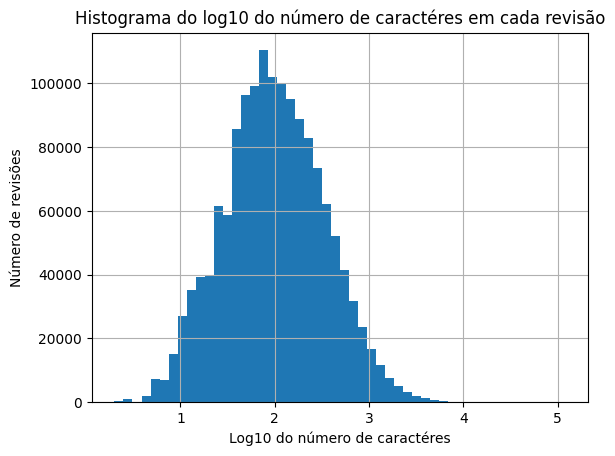

In [ ]:
# Mostra histograma de comprimento das revisões
plt.hist(np.log10(np.array(len_car)+1), bins=50)
plt.title('Histograma do log10 do número de caractéres em cada revisão')
plt.xlabel('Log10 do número de caractéres')
plt.ylabel('Número de revisões')
plt.grid()
plt.show()

In [ ]:
# Comprimento mínimo
min_car = 100

# Comprimento máximo
max_car = 600

textos = []
for i in range(N_reviews):
    if len_car[i]>=min_car:
        if len_car[i]<=max_car:
            textos.append(reviews.iloc[i])

In [ ]:
# Atualiza número de revisões considerando somente as selecionadas
N_reviews = len(textos)
print('Número de revisões seleciondas:', N_reviews)

# Transforma lista de revisões em tensor
textos = np.array(textos)

# Alguns exemplos de textos
print('\n', textos[:5])

Número de revisões seleciondas: 615032

 ['Pode ter ótimos efeitos e blabla, mas n conseguiu me divertir nem me fazer interessar pela história...'
 'Depois de várias tentativas, acho que finalmente tô perdendo o ranço que eu tinha do Adam Devine. Sobre o filme, é fofinho e eu adoro comédias românticas. O problema é que essa premissa de voltar no tempo várias e várias vezes foram feitas num trilhão de filmes só em 2017 então é chatinho assistir mais uma história assim. Mas olha, se tem a Alexandra Daddario eu assisto, então...'
 'E você se pergunta: qual foi o lance em Chinatown? Um dos meus favoritos com tranquilidade. Muito bom.'
 'Um dos meus filmes favoritos. Linda animação. Já ví e reví um milhão de vezes e não enjoo. Belíssima adaptação do romance de Victor Hugo.'
 'Que lindo!! Amo todos os relacionamentos que esse filme se propõe a falar: entre irmão, entre pais e filhos, entre casal! Engraçado que é um filme extremamente simples, mas que deixa o seu recado. E o casal então? Bait

### 2.3 Tokenização dos textos com Keras

Para separar os textos das revisões e depois codificá-los em variáveis categóricas vamos usar a camada `TextVectorization` do Keras.

A camada `TextVectorization` realiza as seguintes operaçãoes:

1. Cria vocabulário de palavras com o número de palavras desejado;
2. Separa os textos em palavras;
3. Codifica as palavras em variáveis categóricas;
4. Coloca cada revisão na forma de uma sequência de números, com o comprimento desejado. Caso a revisão tenho um número menor de palavras do que o desejado, ela é completada com zeros.

Observa-se que o vocabulário de palavras é um dicionário que associa a cada palavra um número.

In [ ]:
# Define comprimento das sequências
seq_len = 100

# Define tamanho do dicionário
vocab_size = 60000

# Cria camada de vetorização de texto
vectorize_layer = TextVectorization(
    #standardize = 'lower',
    max_tokens = vocab_size - 1,
    output_mode = "int",
    output_sequence_length = seq_len + 1, # Pega seq_len +1 palavras para incluir saída desejada para a última palavra
    encoding = 'utf-8')

# Processa texto criando o dicionário de palavras
vectorize_layer.adapt(textos)#[:100])

# Salva dicionário de palavras
vocab = vectorize_layer.get_vocabulary()

In [ ]:
# Primeiras palavras do vocabulário
print('Número de palavras no vocabulário:', len(vocab))
print('Primeiras palavras:', vocab[:1000])

Número de palavras no vocabulário: 59999
Primeiras palavras: ['', '[UNK]', np.str_('que'), np.str_('o'), np.str_('e'), np.str_('de'), np.str_('a'), np.str_('filme'), np.str_('é'), np.str_('um'), np.str_('não'), np.str_('do'), np.str_('uma'), np.str_('com'), np.str_('muito'), np.str_('mas'), np.str_('da'), np.str_('mais'), np.str_('em'), np.str_('se'), np.str_('no'), np.str_('como'), np.str_('eu'), np.str_('os'), np.str_('bem'), np.str_('para'), np.str_('me'), np.str_('esse'), np.str_('na'), np.str_('por'), np.str_('as'), np.str_('dos'), np.str_('pra'), np.str_('bom'), np.str_('foi'), np.str_('ser'), np.str_('tem'), np.str_('história'), np.str_('ao'), np.str_('filmes'), np.str_('melhor'), np.str_('final'), np.str_('só'), np.str_('ele'), np.str_('mesmo'), np.str_('sem'), np.str_('já'), np.str_('achei'), np.str_('ver'), np.str_('são'), np.str_('tão'), np.str_('ter'), np.str_('tudo'), np.str_('isso'), np.str_('até'), np.str_('É'), np.str_('ainda'), np.str_('roteiro'), np.str_('gostei'), np

- Note que o primeiro elemento do vocabulário é um vazio ('') $\to$ isso significa que se tiver um código zero o modelo vai interpretar essa palavra como de fato não existindo.

O elemento com código zero no vocabulário ser vazio é importante porque fazemos padding das sequências de palavras com zeros de forma que todos os exemplos tenham o mesmo comprimento e não queremos que o modelo interprete o "zero" como sendo algo significativo.

Observa-se que camada `TextVectorization` não está preparada para separar a pontuação das palavras do texto.

Se quisermos manter a pontuação devemos usar a opção `standardize='lower'`, mas  com isso palavras que aparecem juntas com alguma pontuação, como por exemplo, "palavra.", "palavra," "palavra!", "palavra:", são codificados com códigos diferentes das mesmas palavras sem a pontuação.

Esse efeito não é conveniente em um modelo que gera textos $\to$ para tokenizar um texto mantendo a pontuação de forma correta, tem-se que usar outras ferramentas.

Uma forma de manter a pontuação do texto e ainda usar a camada `TextVectorization` do Keras, é usar a biblioteca NLTK para separar palavras e pontuações e depois reagrupá-las novamente na forma de uma única string. Essas novas strings podem ser processadas pela camada `TextVectorization` com a opção `standardize = 'lower'`, que a pontuação será mantida. Contudo, observa-se que existem métodos mais eficientes de realizar essa transformação.

Um exemplo de código para processar o texto com a biblioteca NLTK para manter a pontuação é o seguinte:

    # Importa função para separar as palavras das postagens
    import nltk
    from nltk.tokenize import word_tokenize
    nltk.download('punkt')

    # Inicializa lista de textos
    texto_word = []

    # Inicializa comprimento das postagens
    len_revies = []

    # Percorre lista de postagens separando palavras e verificando número de palavras
    for i in range(N_reviews):
        txt = word_tokenize(textos[i])
        txt = [w for w in txt]
        len_i = len(txt)

        # Só guarda postagens maiores do que min_len palavras
        if len_i >= min_len:
            texto_word.append(txt)
            len_reviews.append(len_i)

    # Reagrupa palavras, transformando cada revisão em um única string
    linhas = []
    for i in range(N_reviews):
        txt = ' '.join(texto_word[i])
        linhas.append(txt)
   

In [ ]:
# Alguns exemplos de tokenização
tk = vectorize_layer(textos[:5])
print(tk)

tf.Tensor(
[[  144    51   506   139     4 28370    15   787   305    26  1294    87
     26   118  5537    91    37     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0     0     0     0     0     0     0     0
      0     0     0     0     0]
 [  107     5   369  5508    85     2   698   786  1553     3 13102     2
     22   151    11  1556 22834    62     3     7     8  3060     4    22
    414  1174  2244     3   586     8     2    90  1059     5  1079    20
     71   369     4   369   136   222  1042   328 27748     5    39    42
     18  2735   253     8  2678    60    17    12    37    81    15 

### 2.4 Criação dos exemplos de treinamento

Para criar as entradas e as saídas dos exemplos de treinamento temos que gerar sequencias de entradas e saídas.

As sequências de saídas são iguais às sequências de entradas, porém deslocadas de um palavra para a direita.

Ao deslocar a sequência de saída uma palavra para direita, o modelo aprende a prever as próximas palavras nas sequências, para todas as palavras de cada sequência.

In [ ]:
# Função para preparar dados de entrada
def prepare_inputs_labels(text):
    """
    Para formar as sequências de saída, deslocam-se as sequências de entradas de
    uma posição para a direita, de forma que a saída da posição "i" da sequência
    é a palavra na posição "i+1". Observa-se que o modelo usa todas as palavras
    da sequência prevendo a próxima palavra.
    """
    # Inclui eixo do tempo
    text = tf.keras.ops.expand_dims(text, -1)

    # Realiza o processo de tokenização e criação das sequência com seq_len+1 palavras
    tokenized_sentences = vectorize_layer(text)

    # Define dado de entrada com seq_len primeiras palavras
    x = tokenized_sentences[:, :-1]

    # Define dado de saída com seq_len últimas palavras
    y = tokenized_sentences[:, 1:]

    return x, y

In [ ]:
# Pré processa textos
x_train, y_train = prepare_inputs_labels(textos)
print('Dimensão dos dados de entrada:', x_train.shape)
print('Domensão dos dados de saída:', y_train.shape)

Dimensão dos dados de entrada: (615032, 100)
Domensão dos dados de saída: (615032, 100)


Vamos visualizar alguns exemplos de treinamento criados.

In [ ]:
# Seleciona revisão para mostrar como exemplos
index = 1
print('Sequência de entrada:', x_train[index].numpy())
print('Sequência de saída:', y_train[index].numpy())

Sequência de entrada: [  107     5   369  5508    85     2   698   786  1553     3 13102     2
    22   151    11  1556 22834    62     3     7     8  3060     4    22
   414  1174  2244     3   586     8     2    90  1059     5  1079    20
    71   369     4   369   136   222  1042   328 27748     5    39    42
    18  2735   253     8  2678    60    17    12    37    81    15   613
    19    36     6 23436 39934    22   850   253     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0]
Sequência de saída: [    5   369  5508    85     2   698   786  1553     3 13102     2    22
   151    11  1556 22834    62     3     7     8  3060     4    22   414
  1174  2244     3   586     8     2    90  1059     5  1079    20    71
   369     4   369   136   222  1042   328 27748     5    39    42    18
  2735   253     8  2678    60    17    12    37    81  

Para verificar se a codificação foi realizada corretamente, vamos converter os números em palavras e comparar as duas sequências.

In [ ]:
# Conversão dos códigos de palavras em texto
x = np.array(x_train[index])
input_txt = " ".join([vocab[x_train[index][i]] for i in range(seq_len)])
out_txt = " ".join([vocab[y_train[index][i]] for i in range(seq_len)])

print(f"Texto entrada original antes de processar: \n{textos[index]}\n")
print(f"Texto entrada original após processar: \n{input_txt}\n")
print(f"Texto de saída reconvertido após processamento: \n{out_txt}\n")

Texto entrada original antes de processar: 
Depois de várias tentativas, acho que finalmente tô perdendo o ranço que eu tinha do Adam Devine. Sobre o filme, é fofinho e eu adoro comédias românticas. O problema é que essa premissa de voltar no tempo várias e várias vezes foram feitas num trilhão de filmes só em 2017 então é chatinho assistir mais uma história assim. Mas olha, se tem a Alexandra Daddario eu assisto, então...

Texto entrada original após processar: 
depois de várias tentativas acho que finalmente tô perdendo o ranço que eu tinha do adam devine sobre o filme é fofinho e eu adoro comédias românticas o problema é que essa premissa de voltar no tempo várias e várias vezes foram feitas num trilhão de filmes só em 2017 então é chatinho assistir mais uma história assim mas olha se tem a alexandra daddario eu assisto então                                

Texto de saída reconvertido após processamento: 
de várias tentativas acho que finalmente tô perdendo o ranço que eu tinha do 

## 3. Modelo GPT

Os transformadores pré-treinados generativos (GPT) são uma família de modelos grandes de linguagem (LLM) introduzidos pela OpenAI em 2018.

Como a maioria dos LLMs, os modelos GPT são redes neurais artificiais baseadas na arquitetura de transformador, pré-treinados de forma auto supervisionada usando grandes conjuntos de dados de texto não rotulados.

Entre 2018 e 2023, a OpenAI lançou quatro modelos GPT sendo que cada novo lançamento é significativamente melhor do que o anterior, em razão do aumento do tamanho (medido em número de parâmetros treináveis) e da forma como é realizado o treinamento.

O modelo GPT-3, lançado em 2020, possui 175 bilhões de parâmetros e foi treinados com 400 bilhões de tokens de texto.

A OpenAI tem usado os modelos GPT como base para vários outros produtos e tecnologias, incluindo modelos treinados para seguir instruções, uados no serviço de chatbot ChatGPT.

O termo "GPT" também é usado nos nomes de alguns LLMs generativos não afiliados à OpenAI, como os modelos criados pela EleutherAI (https://6b.eleuther.ai/) e os modelos criados pela Cerebras (https://www.cerebras.net/blog/cerebras-gpt-a-family-of-open-compute-efficient-large-language-models/).

Na Figura 1 é mostrada a arquitetura do GPT e de um bloco transformador.

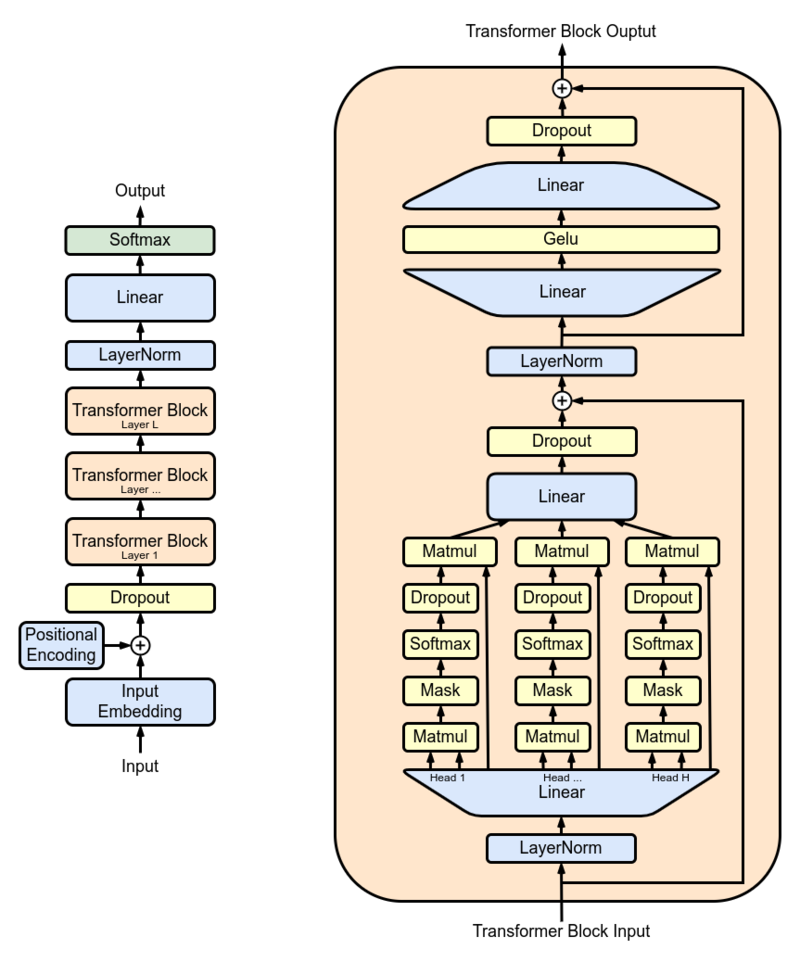

<center>Figura 1 - Configuração do modelo GPT (https://commons.wikimedia.org/wiki/File:Full_GPT_architecture.png)(GPT_architecture.png).<center>

### 3.1 Camadas embedding

Vamos criar duas camadas embedding:

- uma para codificar as palavras;
- outra para codificar a posição das palavras na sequência.

Essas duas camadas embedding são colocadas juntas em uma camada customizada na forma de classe para facilitar a configuração da rede.

Essa camada é instanciada com os sequintes parâmetros:

- Comprimento da sequência de palvras: `seq_len`;
- Número de palavras no dicionário: `vocab_size`;
- Dimensão dos vetores densos: `embed_dim`.

In [ ]:
# Camadas embedding
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, seq_len, vocab_size, embed_dim):
        super().__init__()

        # Salva comprimento máximo das sequências
        self.seq_len = seq_len

        # Instância camada embedding para processar as palavras
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, mask_zero=True)

        # Instância camada embedding para processar posição das palavras
        self.pos_emb = layers.Embedding(input_dim=seq_len, output_dim=embed_dim)

    def call(self, x):
        # Gera vetor de posição das palavras na sequência
        positions = tf.range(start=0, limit=self.seq_len, delta=1)

        # Gera vetores densos das posições
        positions = self.pos_emb(positions)

        # Gera vetores densos das palavras
        x = self.token_emb(x)

        # recupera máscara para lidar com os zeros do padding das sequências
        mask = x._keras_mask

        # Soma os dois vetores densos
        out = x + positions

        return out, mask


- Observa-se que ao instanciar a camada `embedding` para os tokens foi incluido o atributo `mask_zero=True` $\to$ isso deve ser feito quando se usa padding com zeros para fazer com que todas as sequências tenham o mesmo comrpimento. Senão o modelo vai achar que os zeros representam alguma palavra.

- Observa-se, contudo, que nesse caso isso não é necessário porque o código zero no vocabulário reresenta palavra não existente. Isso foi colocado sómente como exemplo que deve ser usado para outros tipos de dados, tais como, séries temporais numéricas.

Vamos testar a camada embedding customizada da seguinte forma:

- Tamanho do lote: 3 sequências;
- Tamanho das sequências de palavras: 10;
- Tamanho do vocabulário: 100;
- Dimensão dos vetores densos: 16.

In [ ]:
# Instância camada embedding customizada
emb_layer = TokenAndPositionEmbedding(10, 100, 16)

# Cria lote de sequencias de entrada
x = np.random.randint(100, size=(3,10))

# Coloca alguns seros para simular padding
x[0,-5:] = 0
x[1,-2:] = 0

# Calcula saída do bloco embedding e recupera a máscara
y, pad_mask = emb_layer(x)

print('Dimensão dos dados de entrada:', x.shape)
print('Um dado do lote de sequências de entrada:', x[0], x[1], x[2])
print('\nDimensão da saída da camada:', y.shape)
print('Uma saída do lote:', y[0])
print('\nDimensão da máscara de padding:', pad_mask.shape)
print('Máscara:', pad_mask)

Dimensão dos dados de entrada: (3, 10)
Um dado do lote de sequências de entrada: [38 46 58 65 47  0  0  0  0  0] [53 27  2 90 96 59  4 95  0  0] [66 46 35 91  8 16 43 20 48 62]

Dimensão da saída da camada: (3, 10, 16)
Uma saída do lote: tf.Tensor(
[[-0.0981193   0.07489467  0.02167078 -0.00253803 -0.05392597 -0.00242275
  -0.06971925  0.04990338  0.02643951  0.02559194 -0.02143499 -0.05234691
   0.04859337 -0.01199933  0.01930248  0.04122957]
 [-0.02634095  0.00484538  0.05399995  0.00090395 -0.01938555  0.00160392
  -0.0718529   0.01688149  0.00845766 -0.03069904  0.04598787  0.03675738
   0.05110998 -0.02280864  0.04307098  0.00088763]
 [ 0.03418774  0.04827642 -0.04387082  0.04103646 -0.01350296 -0.02789348
   0.03173145  0.00308386 -0.00587612 -0.01460987  0.0277457   0.02906371
  -0.02875568 -0.01727353  0.07120516  0.04633658]
 [ 0.02867448 -0.00845754 -0.08277075  0.04257815 -0.01539847  0.08359279
   0.02850385  0.06362081 -0.00643717 -0.00745543 -0.0372575   0.0796052
   0.04

### 3.2 Bloco transformador

Para iniciar a criação de um mini GPT, vamos implementar um bloco transformador causal na forma de uma camada customizada do Keras.

O nome causal vem do termo causalidade, que significa que o estado presente depende somente do passado e não também do futuro.

Observa-se que em modelos de linguagem, o mecanismo de atenção é capaz de processar um sequência completa de dados, de forma que o valor de uma dada posição da sequência (palavra, letra ect) depende tanto do "passado" quanto do "futuro".

Modelos não causais são comuns em tradução de textos.

A causalidade é conseguida no mecanismo de atenção zerando a parte triangular superior das matrizes de atenção. Isso previne que informações de palavras posteriores na sequência sejam usadas.

Na célula abaixo é criada a máscara usada para zerar a parte triangular superior das matrizes de atenção.

In [ ]:
# Função para criar uma máscara com a parte triangular superior igual a zero
def causal_attention_mask(batch_size, n_seq_dest, n_seq_src, dtype):
    """
    batch_size = tamanho do lote de dados
    n_seq_dest = tamanho da sequência resultante
    n_seq_src = tamanho da sequencia de entrada
    """

    causal_mask = tf.linalg.band_part(tf.ones((batch_size, n_seq_dest, n_seq_src), dtype), -1, 0)

    return causal_mask

- A função `tf.linalg.band_part()` serve para criar matrizes com partes zeradas.

- Observa-se que essa máscara pode ser criada com zeros e uns ou com variaveis boolenas (`True` e `False`) $\to$ no modelo deve-se usar variáveis booleanas.

Vamos testar a função `causal_attention_mask()` para entender melhor o seu funcionamento.

In [ ]:
# Define tamanho das sequências de entrada e de saída
n_seq = 10

# Define tamanho do lote
n_batch = 3

# Calcula máscara causal
causal_mask = causal_attention_mask(n_batch, n_seq, n_seq, tf.int32)

print('Dimensão da máscara:', causal_mask.shape)
print('Uma máscara:\n', causal_mask[1].numpy())

Dimensão da máscara: (3, 10, 10)
Uma máscara:
 [[1 0 0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0 0]
 [1 1 1 1 0 0 0 0 0 0]
 [1 1 1 1 1 0 0 0 0 0]
 [1 1 1 1 1 1 0 0 0 0]
 [1 1 1 1 1 1 1 0 0 0]
 [1 1 1 1 1 1 1 1 0 0]
 [1 1 1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1 1 1]]


Observa-se que se quisermos usar a máscara de padding das sequências temos que combinar as duas máscaras. Isso pode ser feito com o seguinte código:

    attn_mask = causal_mask & pad_mask[:, tf.newaxis]

Essa nova máscara deve ser usada na camada de atenção no lugar da máscara causal.

Vamos criar o bloco transformador na forma de uma classe de camada do Keras.

Esse bloco é instânciado com os sequintes parâmetros:

- Dimensão dos vetores densos: `embed_dim`;
- Número de "cabeças" do mecanismo de atenção: `num_heads`;
- Número de unidades das camadas densas: `ff_dim`.

In [ ]:
# Classe de camada Bloco Transformador
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        # Instância camada de atenção com múlticas "cabeças"
        self.att = layers.MultiHeadAttention(num_heads, embed_dim)

        # Instância duas camadas densas para operarem em sequência
        self.ffn = keras.Sequential([layers.Dense(ff_dim, activation="gelu"), layers.Dense(embed_dim),])

        # Instância camadas de normalização
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)

        # Instância camadas de dropout
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, pad_mask):
        # Dimensão da entrada
        input_shape = tf.shape(inputs)

        # Recupera tamanho dos lotes
        batch_size = input_shape[0]

        # Recupera tamanho das sequências
        seq_len = input_shape[1]

        # Calcula máscara causal
        causal_mask = causal_attention_mask(batch_size, seq_len, seq_len, tf.bool)

        # Combina máscaras de padding e causal
        attn_mask = causal_mask & pad_mask[:, tf.newaxis]

        # Executa mecanismo de atenção com dropout na saída
        attention_output = self.att(inputs, inputs, attention_mask=attn_mask)

        # Zera algumas ativações com dropout
        attention_output = self.dropout1(attention_output)

        # Normaliza soma da saída do mecanismo de atenção com as entradas
        out1 = self.layernorm1(inputs + attention_output)

        # Aplica camadas densas com dropout na saída
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output)

        # Normaliza soma da saída da camada densa com saída do mecanismo de atenção normalizda
        out = self.layernorm2(out1 + ffn_output)

        return out

Vamos testar o bloco transformador com as seguintes características:

- lote de 3 exemplos com sequências de 10 números cada;
- vetores densos de 16 elementos.
- número de "cabeças" = 2;
- número de neurônios nas camadas densas: 4.

Observe que a entrada de um bloco transformador são vetores densos, ou seja, as saídas de camadas embedding.



In [ ]:
# Instância bloco transfromador
tf_block = TransformerBlock(16, 2, 4)

# Cria vetores densos de entrada
x = np.random.random((3,10,16))

# Calcula saída do bloco transformador
y = tf_block(x, pad_mask)

print('Dimensão dos dados de entrada:', x.shape)
print('Um dado do lote de vetores densoss:', x[0])
print('\nDimensão da saída do bloco:', y.shape)
print('Uma saída do lote:', y[0])

Dimensão dos dados de entrada: (3, 10, 16)
Um dado do lote de vetores densoss: [[0.00175951 0.21918508 0.66514375 0.5528276  0.49592348 0.60671433
  0.58567244 0.0397866  0.94724064 0.08288988 0.28404719 0.17535591
  0.84691968 0.1609276  0.85355893 0.86388866]
 [0.88137835 0.67616774 0.02262605 0.83792557 0.19808934 0.10030183
  0.97709104 0.51814818 0.86570194 0.9347829  0.60602524 0.68873029
  0.78759752 0.71996393 0.92605628 0.75893757]
 [0.97416052 0.35390652 0.5810881  0.29133401 0.2646946  0.74755697
  0.48951699 0.84611229 0.65683506 0.18850007 0.55182675 0.34388172
  0.39271947 0.08932242 0.82267968 0.22472332]
 [0.21142969 0.61206533 0.05871836 0.09963348 0.91147227 0.14016987
  0.68209042 0.93511839 0.33834055 0.27685028 0.76099897 0.87501201
  0.36896704 0.71037544 0.8776586  0.85197492]
 [0.16769428 0.74166223 0.70972197 0.62326759 0.47218968 0.04985234
  0.8993033  0.69261967 0.80784136 0.62640164 0.82132179 0.90018828
  0.9368464  0.29094569 0.73731643 0.85360257]
 [0.01

### 3.3 Modelo GPT miniatura

A função da célula abaixo cria o modelo GPT miniatura usando as camadas customizadas criadas anteriormente.

Essa função recebe como argumentos os seguintes parâmetros:

1. Tamanho do vocabulario: `vocab_size`;
2. Comprimento da sequência de palavras: `seq_len`;
3. Dimensão dos vetores densor: `emb_dim`;
4. Número de "cabeças" da camada de atenção: `num_heads`;
5. Número de unidades das camadas densas da saída: `feed_forward_dim`.

In [ ]:
# Função para criar modelo GPT miniatura
def create_model(vocab_size, seq_len, embed_dim, num_heads, feed_forward_dim):
    # Define camada de entrada para receber sequências
    inputs = layers.Input(shape=(seq_len,), dtype=tf.int32)

    # Instância camada embedding customizada
    embedding_layer = TokenAndPositionEmbedding(seq_len, vocab_size, embed_dim)

    # Processa entrada com a camada embedding customizada
    x, pad_mask = embedding_layer(inputs)

    # Instância 1o bloco transformador
    transformer_block_1 = TransformerBlock(embed_dim, num_heads, feed_forward_dim)

    # Instância 2o bloco transformador
    transformer_block_2 = TransformerBlock(embed_dim, num_heads, feed_forward_dim)

    # Instância 3o bloco transformador
    transformer_block_3 = TransformerBlock(embed_dim, num_heads, feed_forward_dim)

    # Processa vetores densos com bloco transfromador
    x = transformer_block_1(x, pad_mask)
    x = transformer_block_2(x, pad_mask)
    x = transformer_block_3(x, pad_mask)

    # Processa saída do trasnformador com duas camadas densas para gerar probabilidades (logits)
    x = layers.Dense(2*embed_dim, activation='relu')(x)
    x = layers.Dense(embed_dim)(x)
    outputs = layers.Dense(vocab_size)(x)

    # Cria modelo definindo entrada e saída
    model = keras.Model(inputs=inputs, outputs=outputs)

    return model


Vamos criar o modelo mini chatGPT adequado para o nosso problema.

In [ ]:
# Dimensão dos vetores densos
embed_dim = 256

# Número de "cabeças" do bloco de atenção
num_heads = 4

# Número de neurônios das camadas densas dentro do bloco transfromador
feed_forward_dim = 512

# Cria modelo
model = create_model(vocab_size, seq_len, embed_dim, num_heads, feed_forward_dim)

# Apresenta modelo
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_and_position… │ [(None, 100,      │ 15,385,600 │ input_layer_6[0]… │
│ (TokenAndPositionE… │ 256), (None,      │            │                   │
│                     │ 100)]             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_4 │ (None, 100, 256)  │  1,315,840 │ token_and_positi… │
│ (TransformerBlock)  │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_5 │ (None, 100, 256)  │  1,315,840 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_6 │ (None, 100, 256)  │  1,315,840 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │ token_and_positi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 100, 512)  │    131,584 │ transformer_bloc… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 100, 256)  │    131,328 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 100,       │ 15,420,000 │ dense_21[0][0]    │
│                     │ 60000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,016,032 (133.58 MB)

 Trainable params: 35,016,032 (133.58 MB)

 Non-trainable params: 0 (0.00 B)

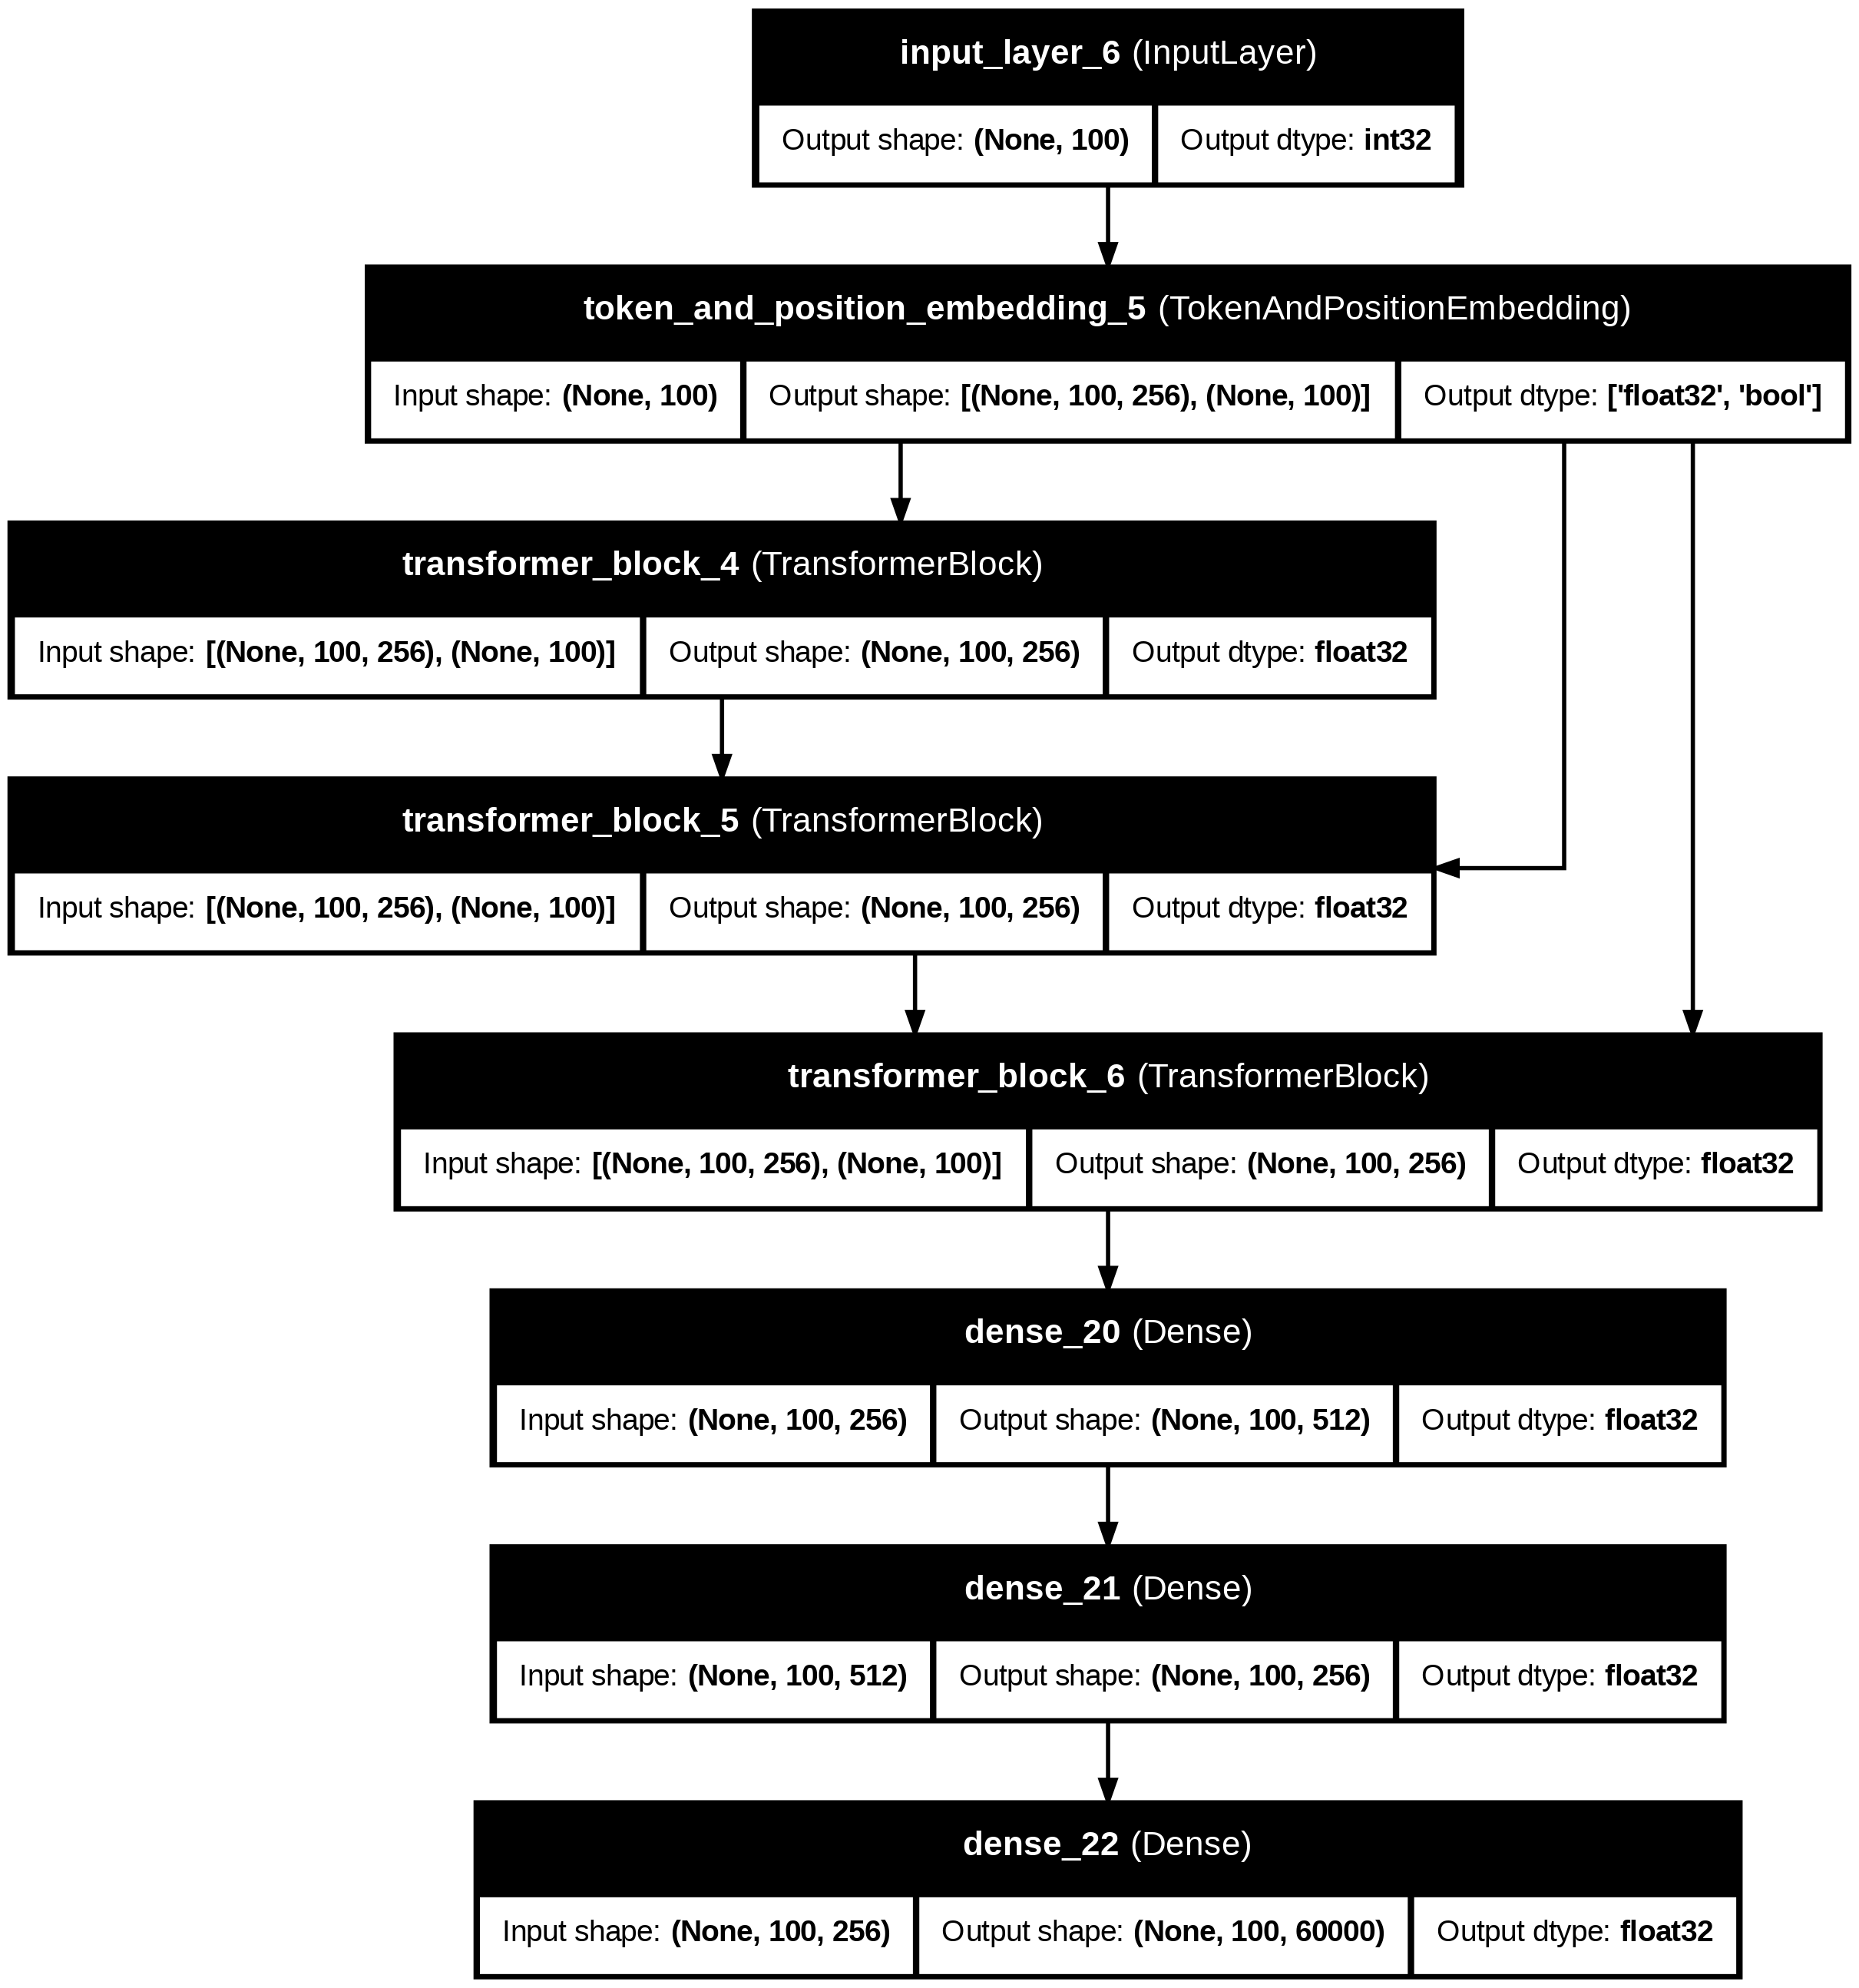

In [ ]:
# Mostra diagrama do modelo
tf.keras.utils.plot_model(model, show_shapes=True, show_dtype=True,
                          show_layer_names=True, expand_nested=True)

Vamos testar o modelo não treinado com alguns exemplos $\to$ lembre que os exemplos de treinamento estão no tensor `x_train`.

In [ ]:
# Executa modelo não terinado
y_teste = model(x_train[:5])

print('Dimensão da saída de teste:', y_teste.shape)

Dimensão da saída de teste: (5, 100, 60000)


## 4. Compilação e treinamento do modelo


### 4.1 Compilação

Para compliar o modelo devemos definir a função de custo e a métrica.

Como temos um problema de classificação multiclasse e as saídas não estão codificadas como vetores one-hot, então, vamos usar a função de custo `SparseCategoricalCrossentropy()`.

Observe que a função de ativação da camada densa de saída é linear, então, na função de custo temos que inlcuir o argumento `from_logits=True`.

A métrica usada é a `SparseCategoricalAccuracy()`.

In [ ]:
# Define função de custo
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Define métrica
metric_fn = tf.keras.metrics.SparseCategoricalAccuracy()

# Compilação modelo
model.compile("adamw", loss=loss_fn, metrics=[metric_fn])

### 4.2 Treinamento do modelo

Para acelerar o treinamento do modelo, vamos usar um número menor de revisões do que processamos.

In [ ]:
results = model.fit(x_train[:300000], y_train[:300000], verbose=1, batch_size=128, epochs=20)

Epoch 1/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 208s 70ms/step - loss: 2.2621 - sparse_categorical_accuracy: 0.6493
Epoch 2/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 124s 53ms/step - loss: 1.9302 - sparse_categorical_accuracy: 0.6725
Epoch 3/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 124s 53ms/step - loss: 1.8499 - sparse_categorical_accuracy: 0.6778
Epoch 4/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 124s 53ms/step - loss: 1.7970 - sparse_categorical_accuracy: 0.6814
Epoch 5/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 124s 53ms/step - loss: 1.7557 - sparse_categorical_accuracy: 0.6843
Epoch 6/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 124s 53ms/step - loss: 1.7216 - sparse_categorical_accuracy: 0.6867
Epoch 7/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 124s 53ms/step - loss: 1.6921 - sparse_categorical_accuracy: 0.6889
Epoch 8/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 124s 53ms/step - loss: 1.6666 - sparse_categorical_accuracy: 0.6909
Epoch 9/20
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 124s 53ms/step - loss: 1.6440 - sparse_categorical_accuracy: 0.6928
Epoch 10/2

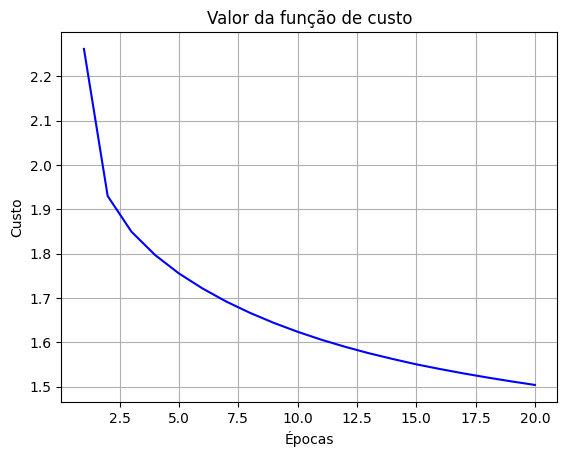

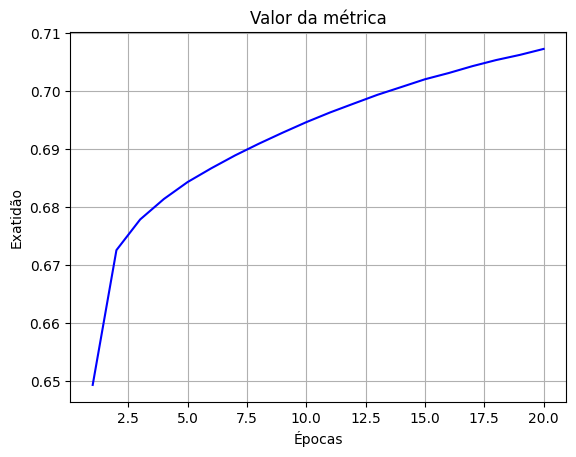

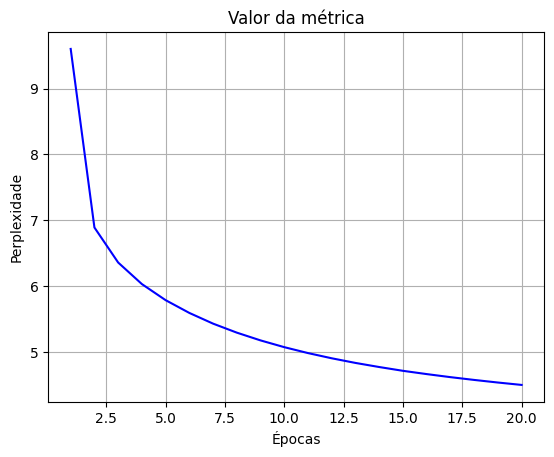

In [ ]:
def plot_train(history):
    history_dict = history.history

    # Salva custos, métricas em vetores
    custo = history_dict['loss']
    perp = np.exp(custo)
    acc = history_dict['sparse_categorical_accuracy']

    # Cria vetor de épocas
    epocas = range(1, len(custo) + 1)

    # Gráfico dos valores de custo
    plt.plot(epocas, custo, 'b', label='Custo - treinamento')
    plt.title('Valor da função de custo')
    plt.xlabel('Épocas')
    plt.ylabel('Custo')
    plt.grid()
    plt.show()

    # Gráfico dos valores da métrica
    plt.plot(epocas, acc, 'b', label='mae')
    plt.title('Valor da métrica')
    plt.xlabel('Épocas')
    plt.ylabel('Exatidão')
    plt.grid()
    plt.show()

    # Gráfico dos valores da métrica
    plt.plot(epocas, perp, 'b', label='perplexidade')
    plt.title('Valor da métrica')
    plt.xlabel('Épocas')
    plt.ylabel('Perplexidade')
    plt.grid()
    plt.show()

plot_train(results)

## 5. Uso do modelo

Para usar o modelo para gerar novas revisões de filmes temos que criar algumas funções para realizar as seguintes operações:

1. Função para amostrar uma palavra do vocabulário a partir das previsões de probabilidades feitas pelo modelo (`sample_from`);
2. Função para realizar a detokenização, ou seja, obter a palavra a partir do seu código numérico (`detokenize`);
3. Função para gerar um texto (`gera_texto`).

Observa-se que é conveniente que a função que amostra uma palavra do vocabulário deve evitar de gerar palavras desconhecidas (UKN).

A Função que gera o texto recebe os seguintes arugmentos:

1. Número de palavras desejado na sequência gerada: `max_tokens`;
2. Lista de strings codificadas em variáveis categóricas do vocabulário para iniciar a geração do texto: `start_tokens`;
3. Dicionário de palavras que mapeia uma variável categórica com a correspondente string: `vocab`;
4. Número de probabilidades usadas par amostrar a próxima palavra: `top_k`.

Para gerar um texto, a função `gera_texto`, realiza as seguintes operações:

1. Executa o modelo com uma sequência inicial pré-definida, para calcular as probabilidades para a próxima palavra da sequência;
2. Amostra as probabilidades calculadas pelo modelo para definir a próxima palavra;
3. Acrescenta essa nova palavra à sequência inicial;
4. Repete as etapas 1 a 3 até gerar o número de palavras desejado.

Observa-se que esse processo de geração de texto é rudimentar $\to$ existem  formas mais eficientes para para criar uma revisão, como por exermplo, terminar a geração quando um ponto final for gerado.

In [ ]:
# Função para amostrar próxima saída das top_k maiores probabilidades
def sample_from(logits, top_k):
    """Argumentos:
          logits: probabilidades previstas pelo modelo
          top_k: número de probabilidades usadas para amostrar próxima palavra
       Saída:
          word_index: índice correspondente à próxima palavra
    """
    # Recupera top_k maiores probabilidades com seus índices (recupera 1 a mais para permitir remove palavra UKN)
    logits, indices = tf.math.top_k(logits, top_k+1, sorted=True)

    # Verifica se UKN é uma das palavras da lista de maior probailidades e se for remove da lista
    # Palavra desconhecida (UKN) tem código 1 no vocabulário
    indices = list(indices)
    logits = list(logits)
    if 1 in indices:
        ind_ukn = indices.index(1)
        indices.remove(1)
        del logits[ind_ukn]
    else:
        logits = logits[:top_k]
        indices = indices[:top_k]

    # Retransforma lista de índices e logits em tensores
    indices = np.asarray(indices).astype("int32")
    logits = np.array(logits)

    # Usa função softmax para calcular probailidades a partir das probabilidades previstas pelo modelo
    preds = keras.activations.softmax(tf.expand_dims(logits, 0))[0]

    # Transforma probabilidades em tensor de reais
    preds = np.asarray(preds).astype("float32")

    # Amostra próxima palavra usando as top_k probabilidades
    word_index = np.random.choice(indices, p=preds)

    return word_index

# Função para obter palavra a partir do seu índice no vocabulario
def detokenize(number, vocab):
    """Argumento: dicionário de vocabulário de palavras
       Saída: string correspondente ao índice da palavra
    """
    return vocab[number]

# Função para gerar texto no final de cada print_every épocas
def gera_texto(model, vocab, start_tokens, max_tokens, top_k):
    """Argumentos:
           model: modelo
           vocab: dicionário de vocabulário de palavras
           star_tokens: sequ~encia inicial
           max_tokens: número de palavras desejadas na revisão
       Saída:
           txt: texto gerado
    """
    # Separa tokens da lista de início
    new_start_tokens = [_ for _ in start_tokens]

    # Inicializa número de palavras geradas
    num_tokens_generated = 0

    # Incializa lista de palavras
    tokens_generated = []

    # Loop para gerar texto
    while num_tokens_generated <= max_tokens:
        # calcula número de zeros a serem colcocados na sequência para ter seq_len valore
        pad_len = seq_len - len(new_start_tokens)

        # Determina índice na sequência da primeira palavra a ser gerada na sequência
        sample_index = len(new_start_tokens) - 1

        # Inclui zeros na sequência de entrada para ter comrpimento igual a seq_len
        if pad_len < 0:
            # Sequência inicial é maior do que seq_len, corta para ter seq_len valores
            x = new_start_tokens[-seq_len:]
            sample_index = seq_len - 1
        elif pad_len > 0:
            # Sequência inicial é menor do que seq_len, preenche com zeros restante da sequência
            x = new_start_tokens + [0] * pad_len
        else:
            # Sequência de entrada tem seq_len elementos
            x = new_start_tokens

        # Transforma lista de tokens em tensor
        x = np.array([x])

        # Realiza previsão do modelo (probabilidades para próxima palavra)
        y = model.predict(x, verbose=0)

        # Amostra próxima palavra usando as top_k maiores probabilidades
        sample_token = sample_from(y[0][sample_index], top_k)

        # Adiciona palavra na lista de palavras
        tokens_generated.append(sample_token)

        # Atualiza lista inicial de palavras, adicionando nova palavra gerada
        new_start_tokens.append(sample_token)

        # Atualiza número de palavras na sequência gerada
        num_tokens_generated = len(tokens_generated)

    # Transforma índices de palavras do vocabulário em palavras (strings)
    new_tokens = start_tokens + tokens_generated
    txt = " ".join([detokenize(_, vocab) for _ in new_tokens])

    return txt, new_tokens

In [ ]:
# Cria dicionário para converter indíces de palavras em strings
word_to_index = {}
for index, word in enumerate(vocab):
    word_to_index[word] = index
print('Dimensão do vocabulário:', len(word_to_index))

# Cria lista de palavras iniciais
start_prompt = "esse filme é ruim"
start_tokens = [word_to_index.get(_, 1) for _ in start_prompt.split()]
print(start_prompt)
print('Lista inicial de índices de palavras:', start_tokens)

# Define número de palavras desejadas na revisão
max_tokens = 30

# Define número de probabilidades usadas para amostrar nova palavra
top_k = 10

# Gera nova revisão de filme
ger_txt, ger_tokens = gera_texto(model, vocab, start_tokens, max_tokens, top_k)

print('Tokens inicial + geradas:\n', ger_tokens)
print('Numero de tokens:', len(ger_tokens))
print(f"Texto gerado:\n{ger_txt}\n")

Dimensão do vocabulário: 59999
esse filme é ruim
Lista inicial de índices de palavras: [27, 7, 8, 197]
Tokens inicial + geradas:
 [27, 7, 8, 197, np.int32(3), np.int32(586), np.int32(8), np.int32(2), np.int32(3), np.int32(7), np.int32(36), np.int32(141), np.int32(59), np.int32(1908), np.int32(4), np.int32(2984), np.int32(410), np.int32(87), np.int32(101), np.int32(15), np.int32(8), np.int32(24), np.int32(163), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0), np.int32(0)]
Numero de tokens: 35
Texto gerado:
esse filme é ruim o problema é que o filme tem algumas cenas forçadas e previsíveis outras nem tanto mas é bem legal            

